# REXIA - Project

# TABULAR DATA 

**Objectif :** Analyse exploratoire d'un jeu de données RH pour prédire les démissions d'employés (variable cible : `label`, où 1 = démission).

## 0. Import & Setup

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Partie 1 - Données Tabulaires

## 1. Analyse du jeu de données

### 1.1 Chargement et première exploration

In [6]:
df = pd.read_csv("RH_dataset.csv", sep=";")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 23857 rows × 14 columns


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


Le jeu de données contient **23 857 observations** (employés) décrites par **14 variables** : temporelles (ancienneté, dernière promotion/augmentation), démographiques (âge, statut marital, parent), professionnelles (famille d'emploi, niveau hiérarchique, salaire) et organisationnelles (établissement). La variable cible `label` vaut 1 si l'employé a démissionné, 0 sinon.

### 1.2 Statistiques descriptives

In [7]:
display(df.describe())

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000
mean,29.460739,7.934986,7.530322,11.632095,20.193947,41.767154,0.720711,1.554554,4168.404032,0.506853,1361.255858,0.031647
std,25.497874,7.549982,5.985476,9.218618,9.295469,11.014444,0.448659,0.657887,1657.829824,0.500299,794.183153,0.175062
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.000000
25%,10.590000,3.180000,2.300000,3.800000,11.000000,34.000000,0.000000,1.000000,3197.000000,0.000000,655.000000,0.000000
50%,21.219999,5.880000,6.280000,9.870000,26.000000,41.000000,1.000000,1.000000,3629.000000,1.000000,1371.000000,0.000000
75%,41.400002,10.340000,11.070000,16.320000,28.000000,49.000000,1.000000,2.000000,4511.000000,1.000000,2072.000000,0.000000
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,1.000000


Quelques observations clés issues des statistiques descriptives :
- **Âge** : entre 20 et ~65 ans, moyenne ≈ 42 ans - population adulte d'âge actif.
- **Salaire** : entre 2 134 € et valeurs élevées, moyenne ≈ 4 168 € - dispersion importante (écart-type ~1 658 €) suggérant des niveaux hiérarchiques très variés.
- **Ancienneté groupe** : moyenne ≈ 11,6 ans, mais forte variabilité - certains employés très récents (< 1 an), d'autres présents depuis plus de 30 ans.
- **Dernière promotion** : moyenne ≈ 29 mois (quasi 2,5 ans), avec des valeurs pouvant dépasser 100 mois - certains employés n'ont pas été promus depuis très longtemps.
- **Label** : moyenne ≈ 0,032, soit environ **3,2 % de démissions** - jeu de données fortement déséquilibré, ce qu'il faudra prendre en compte lors de la modélisation.

### 1.3 Données manquantes

No missing values detected in the dataset.


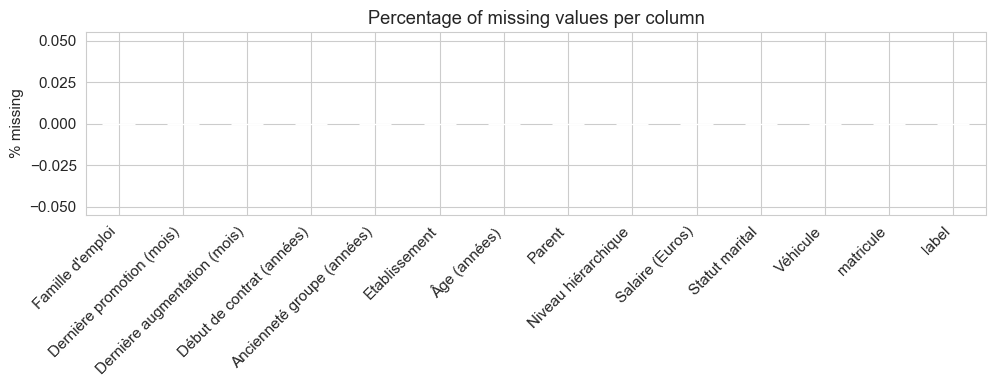

In [8]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing values': missing_counts, 'Percentage (%)': missing_pct})
has_missing = missing_df[missing_df['Missing values'] > 0]
if has_missing.empty:
    print('No missing values detected in the dataset.')
else:
    display(has_missing)

# Bar chart of missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Percentage of missing values per column")
ax.set_ylabel("% missing")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Aucune valeur manquante** n'est détectée dans le jeu de données (toutes les colonnes affichent 23 857 valeurs non-nulles dans `df.info()`). C'est une qualité notable : pas de prétraitement d'imputation nécessaire.

### 1.4 Types de colonnes et modalités

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=[object]).columns.tolist()

print(f"Numerical columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical columns ({len(cat_cols)}):")
for col in cat_cols:
    unique_vals = df[col].unique().tolist()
    print(f"  • {col} ({df[col].nunique()} modalities): {unique_vals}")

Numerical columns (12): ['Dernière promotion (mois)', 'Dernière augmentation (mois)', 'Début de contrat (années)', 'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent', 'Niveau hiérarchique', 'Salaire (Euros)', 'Véhicule', 'matricule', 'label']

Categorical columns (2):
  • Famille d'emploi (8 modalities): ['Production', 'Commercial/Business', 'Etudes & Technique', 'Support', 'IT', 'Développement Immobilier', 'Matériel/Equipement', 'Management']
  • Statut marital (9 modalities): ['Marié(e)', 'PACS', 'Célibataire', 'Divorcé(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'Veuf(ve)', 'ex PACS']


Le jeu de données comprend **12 colonnes numériques** et **2 colonnes catégorielles** :

- **`Famille d'emploi`** (8 modalités) : Production, Commercial/Business, IT, Support, Management, etc. - représente le département ou métier de l'employé.
- **`Statut marital`** (9 modalités) : Marié(e), Célibataire, PACS, Divorcé(e), etc. - variable démographique potentiellement sensible.

Parmi les numériques, noter que **`Parent`** et **`Véhicule`** sont des variables binaires (0/1), **`Niveau hiérarchique`** est ordinale (1 à N), et **`matricule`** est un identifiant sans valeur prédictive - il devra être exclu des modèles.

### 1.5 Distribution de la variable cible

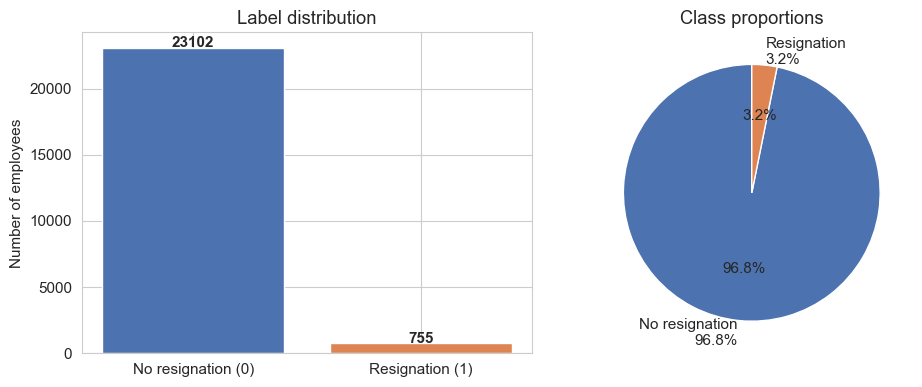

Employees who did not resign : 23102 (96.8%)
Employees who resigned       : 755 (3.2%)


In [11]:
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['No resignation (0)', 'Resignation (1)'], label_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title("Label distribution")
axes[0].set_ylabel("Number of employees")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values,
            labels=[f'No resignation\n{label_pct[0]:.1f}%', f'Resignation\n{label_pct[1]:.1f}%'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Class proportions")

plt.tight_layout()
plt.show()

print(f"Employees who did not resign : {label_counts[0]} ({label_pct[0]:.1f}%)")
print(f"Employees who resigned       : {label_counts[1]} ({label_pct[1]:.1f}%)")

Le jeu de données est **fortement déséquilibré** : seulement ~3,2% des employés ont démissionné. Ce déséquilibre est réaliste (les démissions sont rares dans une grande entreprise), mais il aura un impact important sur la modélisation - des techniques comme le rééchantillonnage (SMOTE, undersampling) ou l'ajustement des poids de classe seront nécessaires pour ne pas biaiser le modèle vers la classe majoritaire.

### 1.6 Distribution des variables numériques

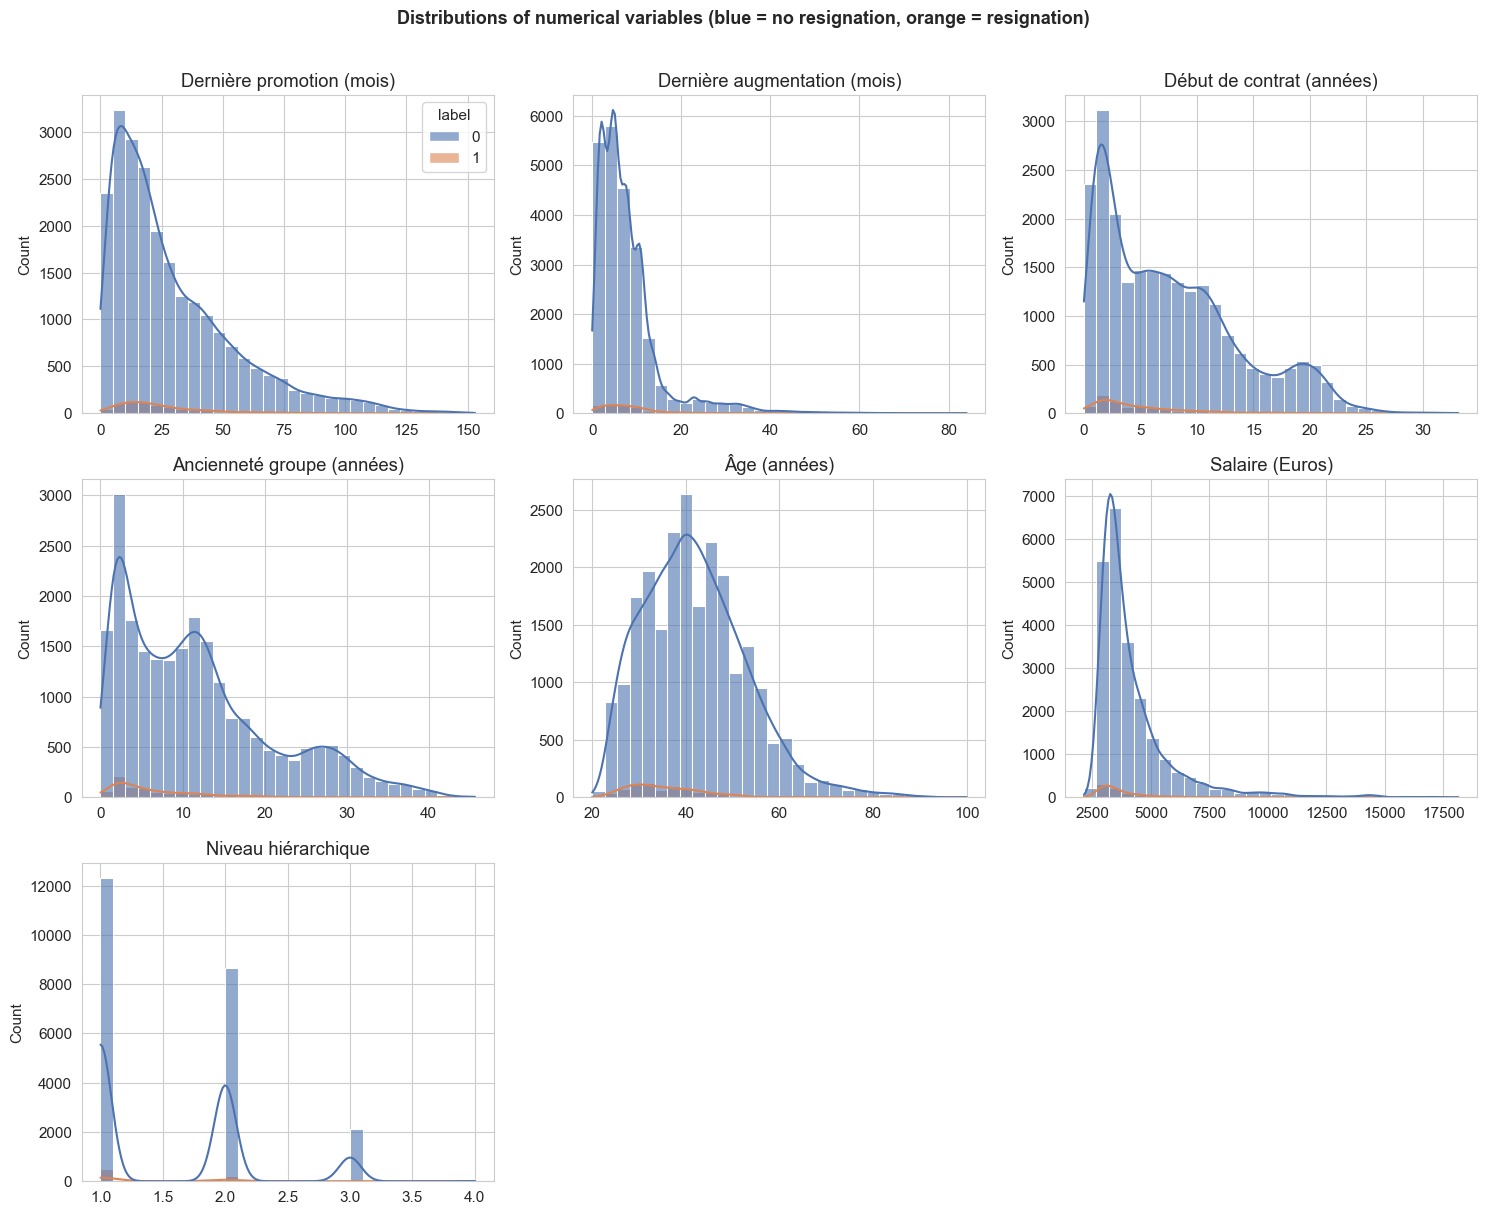

In [12]:
# Relevant continuous columns (excluding matricule, Parent, Véhicule, label)
cont_cols = ['Dernière promotion (mois)', 'Dernière augmentation (mois)',
             'Début de contrat (années)', 'Ancienneté groupe (années)',
             'Âge (années)', 'Salaire (Euros)', 'Niveau hiérarchique']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.histplot(data=df, x=col, hue='label', bins=30, kde=True,
                 ax=axes[i], palette={0: '#4C72B0', 1: '#DD8452'},
                 alpha=0.6, legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide empty axes
for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions of numerical variables (blue = no resignation, orange = resignation)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Plusieurs observations ressortent de ces distributions comparées :

- **Âge** : les démissionnaires sont tendanciellement **plus jeunes** - la distribution orange est décalée vers les 20-35 ans, contrairement aux non-démissionnaires plus centrés sur 40-50 ans.
- **Ancienneté & début de contrat** : les démissions surviennent majoritairement chez des employés avec **peu d'ancienneté** (< 5 ans). Les profils installés dans l'entreprise depuis longtemps démissionnent peu.
- **Dernière augmentation** : les démissionnaires ont souvent reçu leur dernière augmentation **très récemment** (< 5 mois) ou **très tôt dans leur carrière** - ce qui peut indiquer des frustrations salariales persistantes malgré une augmentation de bienvenue.
- **Salaire** : les démissionnaires sont plus concentrés dans les **tranches basses** de salaire.
- **Niveau hiérarchique** : la grande majorité des démissions concerne le **niveau 1** (entrée de hiérarchie), confirmant le lien avec ancienneté et salaire faibles.

### 1.7 Distribution des variables catégorielles

C:\Users\Asturiel\AppData\Local\Temp\ipykernel_10424\500042910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_rate.index, y=family_rate.values, ax=axes[0],
C:\Users\Asturiel\AppData\Local\Temp\ipykernel_10424\500042910.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_rate.index, y=marital_rate.values, ax=axes[1],


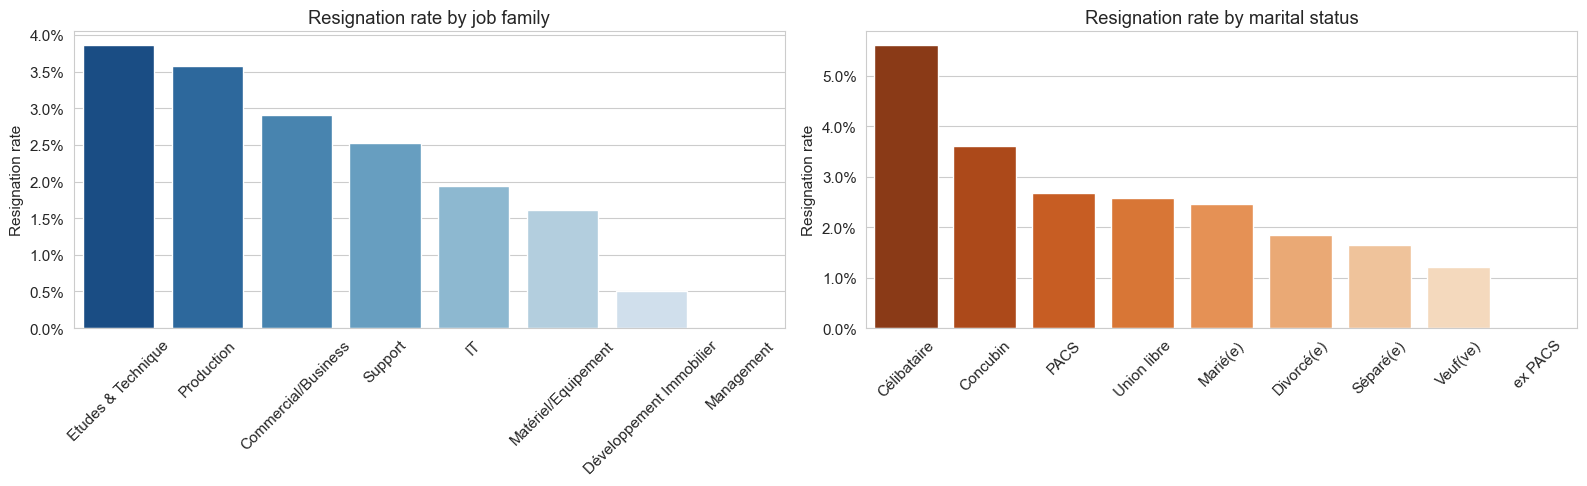

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Resignation rate by job family
family_rate = df.groupby("Famille d'emploi")['label'].mean().sort_values(ascending=False)
sns.barplot(x=family_rate.index, y=family_rate.values, ax=axes[0],
            palette='Blues_r', edgecolor='white')
axes[0].set_title("Resignation rate by job family")
axes[0].set_ylabel("Resignation rate")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Resignation rate by marital status
marital_rate = df.groupby('Statut marital')['label'].mean().sort_values(ascending=False)
sns.barplot(x=marital_rate.index, y=marital_rate.values, ax=axes[1],
            palette='Oranges_r', edgecolor='white')
axes[1].set_title("Resignation rate by marital status")
axes[1].set_ylabel("Resignation rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

- **Famille d'emploi** : certains domaines affichent un taux de démission nettement plus élevé (ex. IT, Commercial). À l'inverse, Production et Management semblent plus stables. Cela peut refléter des tensions sur le marché du travail dans certains secteurs.
- **Statut marital** : les célibataires et les personnes en union libre tendent à démissionner plus souvent - ce qui est cohérent avec une plus grande mobilité géographique et professionnelle. Les profils mariés ou avec enfants (corrélé à la variable `Parent`) semblent plus stables.

### 1.8 Matrice de corrélation

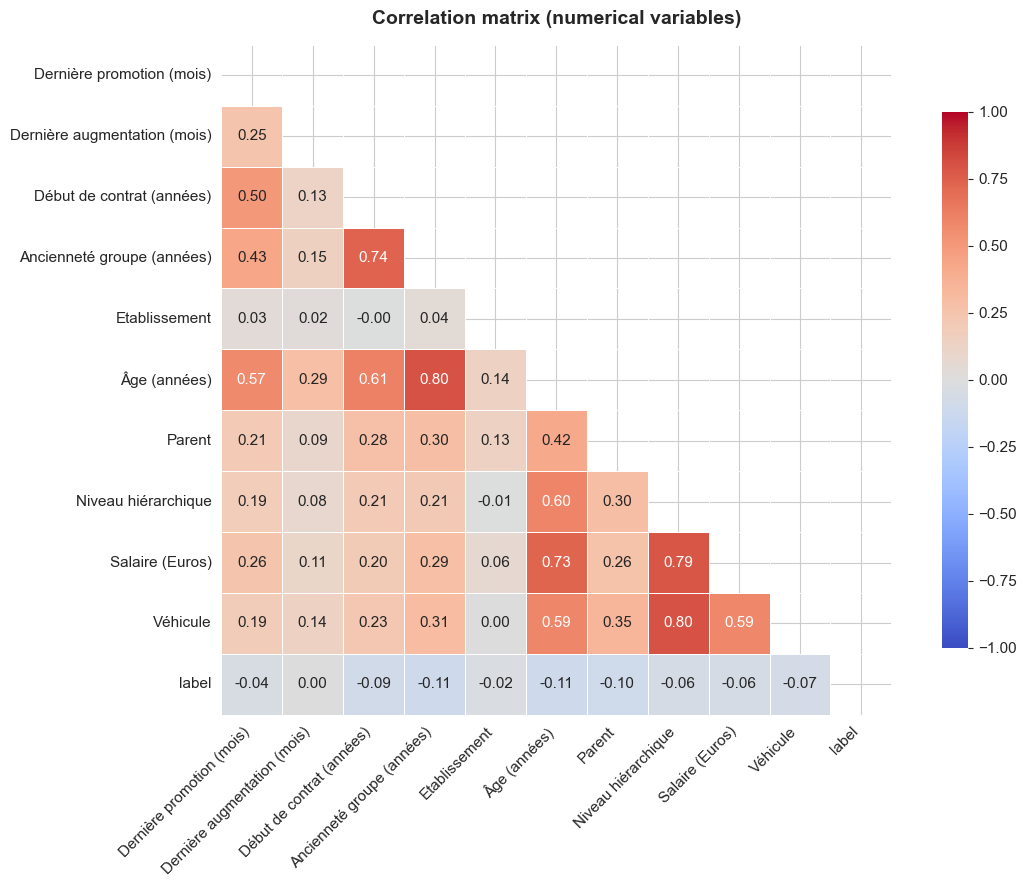

In [14]:
# Exclude matricule (identifier with no predictive value)
df_numeric = df.select_dtypes(include=[np.number]).drop(columns=['matricule'])

corr = df_numeric.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title("Correlation matrix (numerical variables)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analyse de la matrice de corrélation :**

**Corrélations fortes entre variables prédictives :**
- `Ancienneté groupe` et `Début de contrat` sont **très fortement corrélées** (r ≈ 0.95+) - ce qui est logique : plus on est dans le groupe depuis longtemps, plus le contrat a démarré il y a longtemps. Utiliser les deux en modélisation créerait de la multicolinéarité.
- `Âge` et `Ancienneté` sont également corrélées positivement (r ≈ 0.5-0.7) : les employés âgés tendent à avoir plus d'ancienneté.
- `Salaire` et `Niveau hiérarchique` sont corrélés positivement (r ≈ 0.4-0.6) : monter en grade s'accompagne d'une hausse de salaire.

**Corrélations avec le label (démission) :**
- **`label` × `Ancienneté`** : corrélation **négative** - plus l'ancienneté est élevée, moins l'employé démissionne.
- **`label` × `Salaire`** : corrélation **négative** - salaire faible associé à une plus grande probabilité de démission.
- **`label` × `Âge`** : corrélation **négative** - les plus jeunes démissionnent davantage.
- Les corrélations avec `label` restent faibles en valeur absolue (≤ 0.2), ce qui indique que la variable cible est **difficile à prédire par une seule variable seule** - la combinaison de plusieurs variables sera nécessaire.

### 1.9 Analyses complémentaires

C:\Users\Asturiel\AppData\Local\Temp\ipykernel_10424\3210938530.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=axes[i],


ValueError: The palette dictionary is missing keys: {'0', '1'}

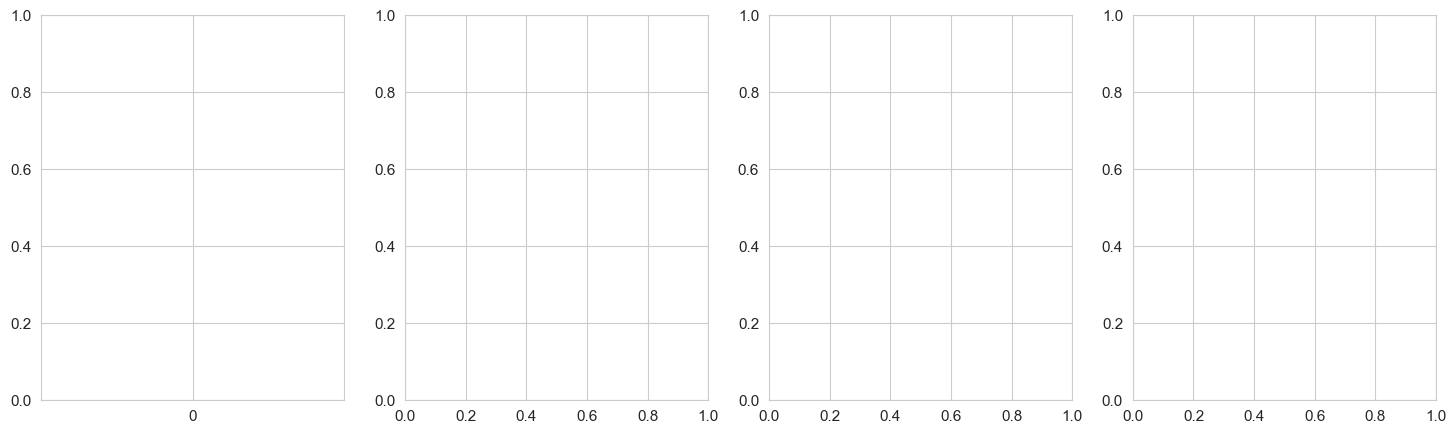

In [15]:
# Boxplots: key variables by label
key_vars = ['Âge (années)', 'Salaire (Euros)', 'Ancienneté groupe (années)', 'Dernière promotion (mois)']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(key_vars):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i],
                palette={0: '#4C72B0', 1: '#DD8452'})
    axes[i].set_title(col)
    axes[i].set_xlabel('Label (0 = stays, 1 = resigns)')
    axes[i].set_xticklabels(['No resignation', 'Resignation'])

fig.suptitle("Distribution of key variables by label", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Les boxplots confirment et précisent les observations précédentes. Les démissionnaires ont des médianes clairement inférieures pour l'âge, le salaire et l'ancienneté. La variable `Dernière promotion` montre davantage de chevauchement entre les deux groupes, ce qui la rend moins discriminante seule.

In [ ]:
# Pairplot of most informative variables
pairplot_cols = ['Âge (années)', 'Salaire (Euros)', 'Ancienneté groupe (années)',
                 'Dernière promotion (mois)', 'label']

g = sns.pairplot(
    df[pairplot_cols].sample(2000, random_state=42),  # sample for readability
    hue='label',
    palette={0: '#4C72B0', 1: '#DD8452'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle("Pairplot - Key variables (sample of 2,000 observations)",
               y=1.02, fontsize=12, fontweight='bold')
plt.show()

Le pairplot permet de visualiser les relations deux à deux. On voit que les démissionnaires (en orange) se concentrent dans le coin bas-gauche de la plupart des graphiques croisés (faible âge × faible salaire × faible ancienneté). Aucune séparation linéaire nette n'est visible, ce qui suggère qu'un modèle non-linéaire (Random Forest, Gradient Boosting) pourrait mieux capturer les interactions entre variables.

In [ ]:
# Resignation rate by establishment
estab_stats = df.groupby('Etablissement').agg(
    n_employees=('label', 'count'),
    n_resignations=('label', 'sum'),
    resignation_rate=('label', 'mean')
).reset_index().sort_values('resignation_rate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(estab_stats['Etablissement'].astype(str),
       estab_stats['resignation_rate'],
       color=plt.cm.RdYlGn_r(estab_stats['resignation_rate'] / estab_stats['resignation_rate'].max()),
       edgecolor='white')
ax.axhline(df['label'].mean(), color='navy', linestyle='--',
           label=f'Global average ({df["label"].mean():.1%})')
ax.set_title("Resignation rate by establishment", fontsize=13, fontweight='bold')
ax.set_xlabel("Establishment")
ax.set_ylabel("Resignation rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend()
plt.tight_layout()
plt.show()

Le taux de démission varie sensiblement d'un établissement à l'autre. Certains établissements affichent un taux nettement au-dessus de la moyenne globale (~3.2%), ce qui pourrait refléter des différences de management local, de conditions de travail ou de composition démographique. Cette variable sera donc utile en modélisation.

### 1.10 Encodage des variables catégorielles (One-Hot Encoding)

On encode les variables catégorielles en colonnes binaires via le **one-hot encoding**. Cette étape est nécessaire pour les algorithmes de machine learning qui ne gèrent pas nativement les chaînes de caractères.

In [ ]:
df_encoded = pd.get_dummies(
    df.drop(columns=['matricule', 'age_group']),
    columns=["Famille d'emploi", 'Statut marital'],
    drop_first=False
)

print(f"Shape after encoding: {df_encoded.shape}")
display(df_encoded.head(3))

Après encodage one-hot des 2 colonnes catégorielles (8 + 9 modalités), le dataframe passe de 14 à environ 29 colonnes. La colonne `matricule` (identifiant sans valeur prédictive) est supprimée. Ce dataframe encodé sera réutilisé pour la phase de modélisation.

## 2. Analyse des biais potentiels et données sensibles

In [ ]:
# Potentially sensitive variables: marital status, parental status, age
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Marital status distribution
marital_counts = df['Statut marital'].value_counts()
axes[0].bar(marital_counts.index, marital_counts.values, color='#4C72B0', edgecolor='white')
axes[0].set_title("Distribution - Marital status")
axes[0].tick_params(axis='x', rotation=45)

# Resignation rate by parental status
parent_rate = df.groupby('Parent')['label'].mean()
axes[1].bar(['No child (0)', 'Parent (1)'], parent_rate.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title("Resignation rate by parental status")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Resignation rate by age group
df['age_group'] = pd.cut(df['Âge (années)'], bins=[18, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])
age_rate = df.groupby('age_group', observed=True)['label'].mean()
axes[2].bar(age_rate.index, age_rate.values, color='steelblue', edgecolor='white')
axes[2].set_title("Resignation rate by age group")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

**Variables sensibles et risques de biais :**

Plusieurs variables du jeu de données soulèvent des questions éthiques et légales dans le contexte RH :

- **`Statut marital`** : La situation matrimoniale est une donnée personnelle protégée. Son inclusion dans un modèle de prédiction de démission pourrait mener à des discriminations indirectes (ex. pénaliser les célibataires à l'embauche ou à la promotion). En France, l'utilisation de telles variables dans les décisions RH est encadrée par la loi (article L1132-1 du Code du travail).

- **`Parent`** : Le fait d'avoir des enfants peut corrélées avec la stabilité professionnelle mais son utilisation dans un modèle RH peut créer des biais discriminatoires selon le genre (les mères étant souvent plus touchées).

- **`Âge (années)`** : Forte corrélation avec le label. Un modèle naïf pourrait apprendre à sur-pénaliser les jeunes employés, ce qui constituerait une discrimination par l'âge.

**Recommandation :** Avant déploiement d'un modèle prédictif, il est conseillé de réaliser une **analyse d'équité algorithmique** (fairness audit) et d'évaluer si le modèle produit des prédictions discriminantes selon ces attributs sensibles - indépendamment de leur pouvoir prédictif statistique.

---
# Partie 2 - Données Images

> *(à compléter)*

# Partie 3 - Données Textuelles

> *(à compléter)*